# The Wronskian, from the ODE Course to Cancer Computational Biology
### A Julia + SciML walkthrough

This notebook is for a student taking a first course in ordinary differential equations (ODEs) who wants to see where the **Wronskian** fits into cancer computational biology and cancer genomics. Along the way it teaches the basics of the **SciML** solver ecosystem ([DifferentialEquations.jl docs](https://docs.sciml.ai/DiffEqDocs/stable/)).

**The honest framing first.** Cancer genomics pipelines almost never contain a step called "compute the Wronskian." The Wronskian lives *underneath* mechanistic ODE models: it is the tool that certifies a set of solutions is **linearly independent**, so they can be combined into the general solution. That same question — *do these components carry genuinely independent information?* — comes back in tumor-response modeling, single-cell RNA velocity, sensitivity analysis and parameter identifiability, which is where machine learning meets mechanistic models.

**Contents**
1. Meet the Wronskian: the idea and three warm-up examples
2. What a student should know (course checklist)
3. A gentle SciML primer
4. Example 1: Two-mode tumor response (drug-sensitive vs. growing fraction)
5. Example 2: Sensitive and resistant clones as a linear system: fundamental matrix + Abel/Liouville check
6. Example 3: RNA velocity (single-cell RNA-seq): when the Wronskian vanishes (repeated roots)
7. Example 4: Variation of parameters rebuilds a clinical tumor-growth model
8. Example 5: Spatial transcriptomics: a signal gradient from the tumor edge (boundary-value problem)
9. Plain-language glossary + roadmap: from the Wronskian to AI/ML in cancer genomics
10. Exercises
11. References

Every example starts with a **Primer** that introduces the biology and the math it uses, assuming no background beyond calculus.

**Prerequisites:** single-variable calculus, 2×2 and 3×3 determinants, basic Julia (or Python, the syntax is close).
**Packages:** `OrdinaryDiffEqTsit5` (the lightweight SciML package that provides the `Tsit5` solver), `Plots`, and the standard library `LinearAlgebra`.

In [1]:
# One-time install (uncomment if needed):
# import Pkg; Pkg.add(["OrdinaryDiffEqTsit5", "Plots"])

using OrdinaryDiffEqTsit5   # SciML ODE solver subpackage (provides ODEProblem, solve, Tsit5)
using LinearAlgebra         # det, eigen, exp (matrix exponential), cond, I
using Plots
default(size = (720, 380), legend = :best, lw = 2, bottom_margin = 5Plots.mm, left_margin = 3Plots.mm)

## 1. Meet the Wronskian

### 1.1 The question it answers
Given a few functions, **can one of them be built from the others by scaling and adding?**
* If yes, the functions are **linearly dependent**: one is redundant and adds nothing new.
* If no, they are **linearly independent**: each brings something the others can't.

Why an ODE course cares: a second-order linear ODE needs **two independent solutions** to build every possible solution, $y = c_1 y_1 + c_2 y_2$. If the two solutions secretly encode the same function (for example $y_2 = 3y_1$), some initial conditions can never be matched.

### 1.2 The tool
The Wronskian (named after Józef Hoene-Wroński) checks independence using each function's **value and slope**:
$$
W[y_1, y_2](t) = \det\begin{pmatrix} y_1(t) & y_2(t) \\ y_1'(t) & y_2'(t) \end{pmatrix} = y_1 y_2' - y_1' y_2 .
$$

**A picture to keep in mind.** At a fixed time $t$, stack each function's value and slope into an arrow: $\mathbf{v}_1 = (y_1, y_1')$ and $\mathbf{v}_2 = (y_2, y_2')$. The Wronskian is the **signed area of the parallelogram** these two arrows span.
* Area $\neq 0$: the arrows point in different directions, so the functions are independent.
* Area $= 0$: the arrows are parallel. If $y_2 = c\,y_1$, then $\mathbf{v}_2 = c\,\mathbf{v}_1$, always parallel, so $W \equiv 0$.

### 1.3 Three warm-up examples (by hand)

**Example A: $y_1 = e^{t}$, $y_2 = e^{2t}$** (solutions of $y'' - 3y' + 2y = 0$, characteristic roots 1 and 2)
$$
W = e^{t}\cdot 2e^{2t} - e^{t}\cdot e^{2t} = e^{3t} \neq 0 \;\Rightarrow\; \text{independent.}
$$
Two different growth rates can never be rescaled into each other.

**Example B: $y_1 = \sin t$, $y_2 = \cos t$** (solutions of $y'' + y = 0$, the simple oscillator)
$$
W = \sin t\,(-\sin t) - \cos t\,\cos t = -(\sin^2 t + \cos^2 t) = -1 \neq 0 \;\Rightarrow\; \text{independent.}
$$
The Wronskian is constant here. Abel's identity (Section 2) predicts this, because the equation has no $y'$ term.

**Example C: $y_1 = 3e^{2t}$, $y_2 = e^{2t}$** (the same curve, rescaled)
$$
W = 3e^{2t}\cdot 2e^{2t} - 6e^{2t}\cdot e^{2t} = 6e^{4t} - 6e^{4t} = 0 \;\Rightarrow\; \text{dependent } (y_1 = 3y_2).
$$

**Bonus, three functions: $1,\ t,\ t^2$.** Each row holds the next derivative:
$$
W = \det\begin{pmatrix} 1 & t & t^2 \\ 0 & 1 & 2t \\ 0 & 0 & 2 \end{pmatrix} = 2 \neq 0 \;\Rightarrow\; \text{independent.}
$$
(The matrix is upper triangular, so the determinant is the product of the diagonal.)

The next cell checks all four by computer and draws the parallelogram picture for Examples A and C.

In [2]:
# Wronskian of 2 functions, given the functions and their derivatives
wronskian2(y1, dy1, y2, dy2, t) = y1(t) * dy2(t) - dy1(t) * y2(t)

tt = 0.7   # any time point works for these examples
println("A: W = ", wronskian2(t -> exp(t), t -> exp(t), t -> exp(2t), t -> 2exp(2t), tt), "   e^(3t) = ", exp(3tt))
println("B: W = ", wronskian2(sin, cos, cos, t -> -sin(t), tt))
println("C: W = ", wronskian2(t -> 3exp(2t), t -> 6exp(2t), t -> exp(2t), t -> 2exp(2t), tt))

# Bonus: 3x3 Wronskian of 1, t, t^2, built row by row (values, 1st derivatives, 2nd derivatives)
W3(t) = det([1 t t^2;
             0 1 2t;
             0 0 2])
println("Bonus: W = ", W3(tt))

A: W = 8.16616991256765

   e^(3t) = 8.166169912567646
B: W = -1.0
C: W = 0.0
Bonus: W = 

2.0


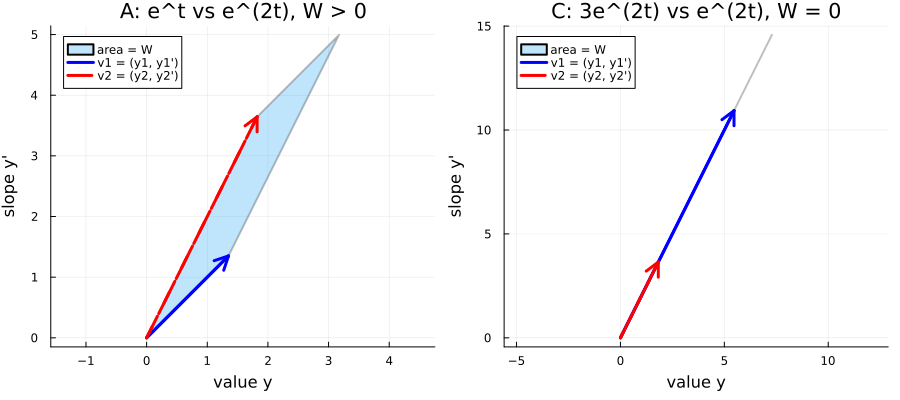

In [3]:
# The parallelogram picture at t = 0.3: arrows v = (value, slope)
function parallelogram(v1, v2, ttl)
    p = plot(Shape([0, v1[1], v1[1] + v2[1], v2[1]], [0, v1[2], v1[2] + v2[2], v2[2]]),
             opacity = 0.25, label = "area = W", title = ttl, xlabel = "value y", ylabel = "slope y'",
             aspect_ratio = :equal)
    plot!(p, [0, v1[1]], [0, v1[2]], arrow = true, lw = 3, color = :blue, label = "v1 = (y1, y1')")
    plot!(p, [0, v2[1]], [0, v2[2]], arrow = true, lw = 3, color = :red, ls = :dash, label = "v2 = (y2, y2')")
    p
end
t0 = 0.3
pA = parallelogram([exp(t0), exp(t0)], [exp(2t0), 2exp(2t0)], "A: e^t vs e^(2t), W > 0")
pC = parallelogram([3exp(2t0), 6exp(2t0)], [exp(2t0), 2exp(2t0)], "C: 3e^(2t) vs e^(2t), W = 0")
plot(pA, pC, layout = (1, 2), size = (900, 400), legend = :topleft)

In panel A the arrows span a real parallelogram (nonzero area). In panel C they lie on the same line (zero area): $y_1$ is just $y_2$ stretched by 3.

**One-sentence summary to carry into the examples:** *the Wronskian is nonzero exactly when the building blocks of a solution are genuinely different from one another.*

## 2. What a student should know (course checklist)

In a standard one-semester ODE course (for example one using Nagle, Saff & Snider's *Fundamentals of Differential Equations*, or Boyce & DiPrima), the Wronskian appears in these units:

| Course unit | Where the Wronskian shows up |
|---|---|
| Second-order homogeneous, constant coefficients | Checking that $\{y_1, y_2\}$ is a **fundamental solution set** |
| Repeated roots | Why $te^{rt}$ is needed as the second solution |
| Variation of parameters | $W$ is the denominator of the formulas |
| Higher-order theory | $n \times n$ Wronskian, Abel's identity |
| Higher-order variation of parameters | Cramer's rule with $W_k / W$ |
| Systems $\mathbf{x}' = A\mathbf{x}$ | $W = \det X(t)$ of the **fundamental matrix**, Liouville's formula |

### 1.1 Definition
For two differentiable functions,
$$
W[y_1, y_2](t) = \det\begin{pmatrix} y_1 & y_2 \\ y_1' & y_2' \end{pmatrix} = y_1 y_2' - y_1' y_2 .
$$
For $n$ functions, row $k$ holds the $(k-1)$-th derivatives:
$$
W[y_1,\dots,y_n] = \det\begin{pmatrix} y_1 & \cdots & y_n \\ y_1' & \cdots & y_n' \\ \vdots & & \vdots \\ y_1^{(n-1)} & \cdots & y_n^{(n-1)} \end{pmatrix}.
$$

### 1.2 The independence test (know both directions and the caveat)
* If $W(t_0) \neq 0$ at **some** point, the functions are linearly independent.
* For **solutions** of a linear ODE $y'' + p(t)y' + q(t)y = 0$ with $p, q$ continuous on an interval $I$: $W$ is either **never zero** or **identically zero** on $I$, and the solutions are independent ⇔ $W \neq 0$.
* **Caveat:** for *arbitrary* functions, $W \equiv 0$ does **not** prove dependence. The classic counterexample is $y_1 = t^2$, $y_2 = t|t|$: $W \equiv 0$ on $\mathbb{R}$, yet they are independent on any interval containing $0$.

### 1.3 Abel's identity
For $y'' + p(t)y' + q(t)y = 0$,
$$
W(t) = W(t_0)\, \exp\!\Big(-\int_{t_0}^{t} p(s)\, ds\Big).
$$
This explains the "never zero or always zero" rule: an exponential is never zero.

### 1.4 General solution and initial-value problems
If $W \neq 0$, then $y = c_1 y_1 + c_2 y_2$ is the general solution, and $c_1, c_2$ for $y(t_0)=a,\ y'(t_0)=b$ come from a linear system whose coefficient determinant **is** $W(t_0)$. So "$W \neq 0$" literally means "every initial condition can be matched."

### 1.5 Variation of parameters
For $y'' + p y' + q y = g(t)$ with fundamental set $\{y_1, y_2\}$:
$$
y_p = -y_1 \int \frac{y_2\, g}{W}\, dt + y_2 \int \frac{y_1\, g}{W}\, dt .
$$
(The equation must be in **standard form**, with leading coefficient 1, before reading off $g$.)

### 1.6 Systems
For $\mathbf{x}' = A(t)\mathbf{x}$ with $n$ solution vectors as columns of $X(t)$ (the **fundamental matrix**), $W(t) = \det X(t)$, and **Liouville's formula** (Abel's identity for systems) is
$$
\det X(t) = \det X(t_0)\, \exp\!\Big(\int_{t_0}^{t} \operatorname{tr} A(s)\, ds\Big).
$$
For constant $A$ with $X(0) = I$: $X(t) = e^{At}$ and $\det e^{At} = e^{t\,\operatorname{tr}A}$.

In [4]:
# Sanity check on the caveat example: t^2 and t|t| (derivatives 2t and 2|t|)
y1(t) = t^2;    dy1(t) = 2t
y2(t) = t*abs(t); dy2(t) = 2abs(t)
[wronskian2(y1, dy1, y2, dy2, t) for t in -2:1.0:2]   # all zero, yet independent on [-2, 2]

5-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0

## 3. A gentle SciML primer

**What a numerical ODE solver does.** Most ODEs that come up in biology have no formula for their solution. A solver starts at the initial condition and takes many small steps forward, each time using the equation to estimate the slope and moving a little in that direction. Good solvers (like `Tsit5`, a Runge–Kutta method) choose the step size automatically: small steps where the solution changes fast, big steps where it is calm. The **tolerances** `reltol`/`abstol` set how much error each step may introduce. Smaller is more accurate but slower.

**Vocabulary used below:**
* `u` is the state (the unknown function's value, a number or a vector), `t` is time, and `p` holds the **parameters** (rates such as growth or kill rate).
* `f(u, p, t)` returns the derivative $du/dt$. It is literally the right-hand side of the ODE.
* `tspan = (t_start, t_end)` is the time window to solve over.

The SciML workflow (from the [Getting Started page](https://docs.sciml.ai/DiffEqDocs/stable/getting_started/)) is always the same three steps:

1. **Define** the right-hand side `f(u, p, t)` (out-of-place) or `f!(du, u, p, t)` (in-place, faster).
2. **Build** an `ODEProblem(f, u0, tspan, p)`.
3. **Solve** with `solve(prob, Tsit5())`. `Tsit5` is the recommended default non-stiff solver.

What to know about the solution object:
* `sol.t` are the time steps and `sol.u` the states; `sol[i]` means the *i*-th step.
* `sol(t)` **interpolates** at any time $t$ (a continuous solution, not just grid points).
* Keywords: `saveat = 0.1` for fixed output times; `reltol`, `abstol` for accuracy.
* `u0` can be a **matrix**; then `f` must return a matrix. Example 2 uses this to integrate a whole fundamental matrix at once.

(`using DifferentialEquations` loads everything; the docs note that individual solver packages such as `OrdinaryDiffEqTsit5` can be loaded instead to keep installs light, which is what this notebook does.)

**Warm-up:** exponential tumor growth $N' = rN$, solved numerically and compared with $N_0 e^{rt}$.

steps taken: 92


N(7.5) numerical = 

9.487735836402788   exact = 9.487735836358526


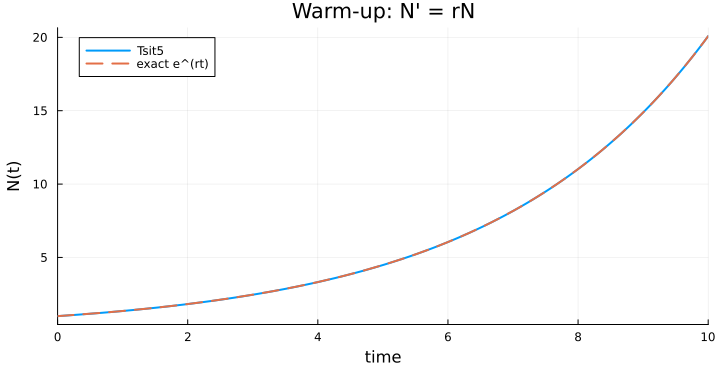

In [5]:
growth(N, p, t) = p.r * N                     # out-of-place RHS: f(u, p, t)
prob = ODEProblem(growth, 1.0, (0.0, 10.0), (r = 0.3,))
sol  = solve(prob, Tsit5(); reltol = 1e-10, abstol = 1e-10)

println("steps taken: ", length(sol.t))
println("N(7.5) numerical = ", sol(7.5), "   exact = ", exp(0.3 * 7.5))
plot(sol, label = "Tsit5", xlabel = "time", ylabel = "N(t)", title = "Warm-up: N' = rN")
plot!(t -> exp(0.3t), 0, 10, ls = :dash, label = "exact e^(rt)")

## 4. Example 1: Two-mode tumor response

> **Primer: the biology.** *Tumor burden* is how much tumor a patient has. It is measured from scans (for example the sum of tumor diameters) or from a blood marker; in prostate cancer the usual marker is **PSA** (prostate-specific antigen). Tumors are **heterogeneous**: under treatment some cells respond and die, while others keep growing. A patient's burden curve is therefore often a *mixture* of a falling part and a rising part.
>
> **Primer: the math.**
> * **Exponential decay $e^{-dt}$:** a population in which a fixed fraction dies per unit time. $d$ is the *rate*; the half-life is $\ln 2 / d$.
> * **Exponential growth $e^{gt}$:** a fixed fraction is added per unit time; the doubling time is $\ln 2 / g$.
> * **Mode:** one simple building-block solution. The full curve is a weighted sum of modes, $N(t) = C_1 e^{-dt} + C_2 e^{gt}$.
> * **Least squares:** given noisy measurements $N(t_i)$, choose $C_1, C_2$ to minimize the sum of squared errors. The **design matrix** has one column per mode, evaluated at the measurement times. Julia solves this with `A \ y`.
> * **Condition number** (`cond`): how much noise in the data gets amplified in the fitted answer. Around 1–10 is healthy; hundreds or more means the fit is fragile. It is large when the columns of the design matrix are nearly parallel, which is the data version of a near-zero Wronskian.

Stein, Figg and colleagues (NCI) modeled tumor burden during therapy as the sum of a **regressing** component and a **growing** component:
$$
f(t) = e^{-dt} + e^{gt} - 1,
$$
with regression rate $d$ and growth rate $g$, normalized so $f(0) = 1$. In their prostate-cancer trials the **growth rate $g$ correlated with survival, while $d$ did not** (Stein et al., *Clin Cancer Res* 2011).

The two **modes** are $y_1 = e^{-dt}$ (drug-sensitive cells dying) and $y_2 = e^{gt}$ (a fraction that keeps growing). Are they genuinely independent?

**By hand:**
$$
W = \begin{vmatrix} e^{-dt} & e^{gt} \\ -d e^{-dt} & g e^{gt} \end{vmatrix} = (g + d)\, e^{(g-d)t}.
$$
So $W \neq 0$ **unless $g = -d$**, the case where the "growing" fraction actually decays at exactly the sensitive rate, making the two modes the same curve.

**Why a data scientist should care.** Fitting $N(t) \approx C_1 y_1 + C_2 y_2$ to measurements is linear least squares with design-matrix columns $y_1(t_i), y_2(t_i)$. As $g \to -d$ the columns become nearly parallel, the matrix becomes ill-conditioned, and $C_1, C_2$ stop being **identifiable** from data. The Wronskian is the continuous-time version of "are the columns of the design matrix independent?"

g = 0.1:  W(3) numeric = 0.18071652714732125   formula (g+d)e^((g-d)t) = 0.1807165271473212
g = -0.2:  W(3) numeric = 0.03673692847589456   formula (g+d)e^((g-d)t) = 0.03673692847589459


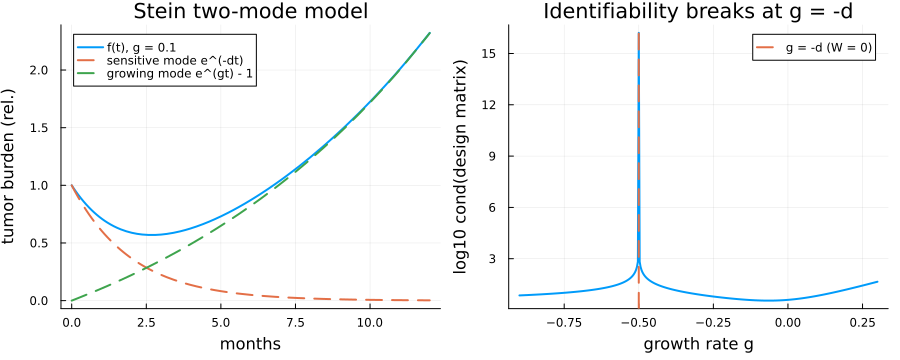

In [6]:
d = 0.5                       # regression rate (per month, illustrative)
W1(t, g) = (g + d) * exp((g - d) * t)

# numeric check of the hand formula at a few points
y1(t) = exp(-d*t);       dy1(t) = -d*exp(-d*t)
for g in (0.1, -0.2)
    numeric = wronskian2(y1, dy1, t -> exp(g*t), t -> g*exp(g*t), 3.0)
    println("g = $g:  W(3) numeric = ", numeric, "   formula (g+d)e^((g-d)t) = ", W1(3.0, g))
end

# Conditioning of the least-squares design matrix as g -> -d
ts = range(0, 12, length = 25)
gs = range(-0.9, 0.3, length = 400)
condnum = [cond(hcat(exp.(-d .* ts), exp.(g .* ts))) for g in gs]

p1 = plot(gs, log10.(condnum), xlabel = "growth rate g", ylabel = "log10 cond(design matrix)",
          label = "", title = "Identifiability breaks at g = -d")
vline!(p1, [-d], ls = :dash, label = "g = -d (W = 0)")
p2 = plot(t -> exp(-d*t) + exp(0.1t) - 1, 0, 12, label = "f(t), g = 0.1",
          xlabel = "months", ylabel = "tumor burden (rel.)", title = "Stein two-mode model")
plot!(p2, t -> exp(-d*t), 0, 12, ls = :dash, label = "sensitive mode e^(-dt)")
plot!(p2, t -> exp(0.1t) - 1, 0, 12, ls = :dash, label = "growing mode e^(gt) - 1")
plot(p2, p1, layout = (1, 2), size = (900, 360))

In [7]:
# Fit C1, C2 from noisy synthetic data, 500 times per g, and look at the spread
import Random, Statistics; Random.seed!(1)
function fit_spread(g; noise = 0.02, reps = 500)
    A = hcat(exp.(-d .* ts), exp.(g .* ts))
    fits = [A \ (A * [1.0, 0.3] .+ noise .* randn(length(ts))) for _ in 1:reps]   # true C = (1.0, 0.3)
    (cond = cond(A), sdC1 = Statistics.std(first.(fits)), sdC2 = Statistics.std(last.(fits)))
end
for g in (0.10, -0.45, -0.495)
    r = fit_spread(g)
    println("g = $g:  W(0) = ", round(W1(0, g), digits = 3), "   cond = ", round(r.cond, sigdigits = 3),
            "   sd(C1) = ", round(r.sdC1, sigdigits = 2), "   sd(C2) = ", round(r.sdC2, sigdigits = 2))
end

g = 0.1:  W(0) = 0.6

   cond = 6.88   sd(C1) = 0.013   sd(C2) = 0.0021
g = -0.45:  W(0) = 0.05   cond = 38.4   sd(C1) = 0.25   sd(C2) = 0.24
g = -0.495:  W(0) = 0.005   cond = 402.0   sd(C1) = 2.5   sd(C2) = 2.5


**Takeaway.** Same noise, same number of time points: when the modes are well separated ($g = 0.1$), repeated fits land within about ±0.01 of the truth. As $g \to -d$, the Wronskian shrinks toward zero, the condition number grows, and the spread of the estimates grows about 200-fold, to roughly ±2.5 at $g = -0.495$. Any single fit there can come out far from the truth. That is the practical face of a near-zero Wronskian: the data cannot tell the two modes apart.

## 5. Example 2: Sensitive and resistant clones (fundamental matrix + Liouville)

> **Primer: the biology.** A **clone** is a group of cancer cells descended from one ancestor cell, sharing its mutations. Under a targeted drug, **sensitive** cells die, but now and then a cell acquires a mutation that makes it **resistant**. The resistant clone is tiny at first, keeps growing during treatment, and eventually causes **relapse**: the tumor shrinks, then grows back.
>
> **Primer: the math.**
> * **System of ODEs:** two (or more) quantities whose rates of change depend on each other. Here $S$ (sensitive) feeds $R$ (resistant) through mutation.
> * **Matrix form $\mathbf{x}' = A\mathbf{x}$:** just bookkeeping. Row $i$ of $A$ says how each variable contributes to the rate of change of variable $i$.
> * **Eigenvalues of $A$:** the growth/decay rates of the system's modes, the system version of the characteristic roots from the course. For a triangular matrix they are simply the diagonal entries.
> * **Fundamental matrix $X(t)$:** independent solutions placed side by side as columns. Starting from $X(0) = I$ means "one solution starts with only sensitive cells, the other with only resistant cells."
> * **Wronskian for systems** $= \det X(t)$. **Trace** $\operatorname{tr} A$ = sum of the diagonal entries. **Liouville's formula** says the Wronskian grows or shrinks at a rate equal to the trace, with no need to solve the system.
> * **Matrix exponential $e^{At}$:** the system version of $e^{at}$. When $X(0) = I$, the fundamental matrix *is* $e^{At}$.

A minimal linear model of a tumor under continuous therapy, in the spirit of the resistance-evolution literature (e.g. Foo & Michor 2009), but deliberately simplified so it stays linear:

$$
\begin{aligned}
S' &= -(k + \mu)\, S && \text{sensitive cells: killed at rate } k,\ \text{mutate to resistance at rate } \mu\\
R' &= \mu S + r R && \text{resistant cells: fed by mutation, grow at net rate } r
\end{aligned}
\qquad\Longleftrightarrow\qquad
\mathbf{x}' = A\mathbf{x},\quad A = \begin{pmatrix} -(k+\mu) & 0 \\ \mu & r \end{pmatrix}.
$$

**Fundamental matrix trick (SciML).** Solve $X' = AX$ with **matrix** initial condition $X(0) = I$. Each column is an independent solution, and $W(t) = \det X(t)$. Then verify three ways:
1. against the matrix exponential $e^{At}$ (`exp(A*t)` in Julia);
2. against **Liouville**: $\det X(t) = e^{t\,\operatorname{tr}A} = e^{(r - k - \mu)t}$;
3. that $W$ never crosses zero (it is an exponential).

In [8]:
k, μ, r = 0.6, 1e-3, 0.08          # kill rate, mutation rate, resistant growth (per day, illustrative)
A = [-(k + μ) 0.0;
      μ       r ]

fundamental!(dX, X, A, t) = mul!(dX, A, X)      # in-place: dX = A*X  (X is a 2x2 matrix)
probX = ODEProblem(fundamental!, Matrix(1.0I, 2, 2), (0.0, 40.0), A)
solX  = solve(probX, Tsit5(); reltol = 1e-10, abstol = 1e-12)

for t in (5.0, 20.0, 40.0)
    X = solX(t)
    println("t = $t:  det X = ", round(det(X), sigdigits = 8),
            "   Liouville e^(t tr A) = ", round(exp(t * tr(A)), sigdigits = 8),
            "   max|X - exp(At)| = ", round(maximum(abs.(X .- exp(A * t))), sigdigits = 2))
end

t = 5.0:  det X = 0.073903137

   Liouville e^(t tr A) = 0.073903137   max|X - exp(At)| = 7.1e-13
t = 20.0:  det X = 2.982988e-5   Liouville e^(t tr A) = 2.9829879e-5   max|X - exp(At)| = 1.7e-13
t = 40.0:  det X = 8.8982338e-10   Liouville e^(t tr A) = 8.8982171e-10   max|X - exp(At)| = 7.1e-11


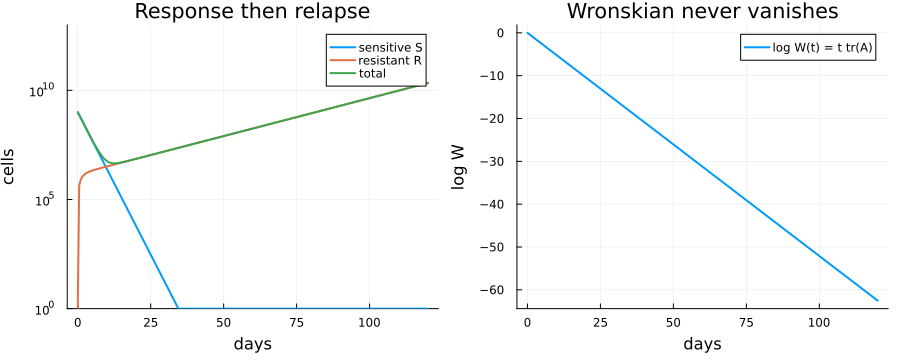

In [9]:
# The biology: start with 1e9 sensitive cells, 0 resistant
x0 = [1e9, 0.0]
clones(x, A, t) = A * x
solC = solve(ODEProblem(clones, x0, (0.0, 120.0), A), Tsit5(); saveat = 0.5)

# clamp at 1 cell for the log plot (R(0) = 0, and S falls below one cell)
S = max.(getindex.(solC.u, 1), 1.0); R = max.(getindex.(solC.u, 2), 1.0)
p1 = plot(solC.t, [S R S .+ R], yscale = :log10, ylims = (1, 1e13),
          label = ["sensitive S" "resistant R" "total"], xlabel = "days", ylabel = "cells",
          title = "Response then relapse")
tW = range(0, 120, length = 200)
p2 = plot(tW, t -> tr(A) * t, label = "log W(t) = t tr(A)", xlabel = "days", ylabel = "log W",
          title = "Wronskian never vanishes")
plot(p1, p2, layout = (1, 2), size = (900, 360))

**Reading it.** The total burden first drops (sensitive cells die), then rebounds as the resistant clone, seeded by rare mutations, takes over: the classic response-then-relapse curve. The eigenvalues of $A$ are $-(k+\mu)$ and $r$, so the solution is again a **two-mode** combination, as in Example 1. Liouville's formula gives the Wronskian without solving anything: only the **trace** matters.

## 6. Example 3: RNA velocity (single-cell RNA-seq), where the Wronskian vanishes

> **Primer: the biology.** A gene is first copied (**transcribed**) into *pre-mRNA*, which still contains non-coding stretches called **introns**. **Splicing** cuts the introns out, producing *mature (spliced) mRNA*, which is eventually **degraded**. **Single-cell RNA-seq** (scRNA-seq) sequences the RNA of thousands of individual cells; reads that land in introns reveal unspliced molecules. A gene that has just been switched **on** has extra unspliced RNA relative to spliced, and a gene being switched **off** has a deficit. That imbalance shows which way each cell's expression is heading, its *velocity*. In tumors this is used to ask, for example, which direction cells are differentiating or changing state.
>
> **Primer: the math.**
> * **Rates:** $\alpha$ = transcription (production of unspliced RNA), $\beta$ = splicing (unspliced → spliced), $\gamma$ = degradation of spliced RNA.
> * The model is a **linear system with constant coefficients**, the same type as Example 2, plus a constant input $\alpha$.
> * **Repeated roots, a refresher:** for $y'' + 2y' + y = 0$ the characteristic equation $(r+1)^2 = 0$ has the single root $-1$, twice. $e^{-t}$ is one solution, but "$e^{-t}$ again" adds nothing new. The second, independent solution is $te^{-t}$. The Wronskian is how the course proves that $te^{-t}$ really is new.

**RNA velocity** (La Manno et al. 2018; Bergen et al. 2020, scVelo) infers the direction cells are moving in expression space from single-cell RNA-seq, using unspliced ($u$) and spliced ($s$) mRNA counts per gene:
$$
\frac{du}{dt} = \alpha - \beta u, \qquad \frac{ds}{dt} = \beta u - \gamma s,
$$
with transcription rate $\alpha$, splicing rate $\beta$ and degradation rate $\gamma$. This is a linear, constant-coefficient system, so it is squarely course material.

**Homogeneous part.** Eliminating $u$ gives a second-order equation for $s$ with characteristic roots $-\beta$ and $-\gamma$.
* If $\beta \neq \gamma$: modes $e^{-\beta t}, e^{-\gamma t}$, with $W = (\beta - \gamma)\,e^{-(\beta+\gamma)t} \neq 0$.
* If $\beta = \gamma$ (**repeated root**): the "two" modes are the same function, so $W[e^{-\gamma t}, e^{-\gamma t}] \equiv 0$. The fix taught in the course is $\{e^{-\gamma t},\ t e^{-\gamma t}\}$, with $W = e^{-2\gamma t} \neq 0$.

**Why this matters in practice.** The textbook closed form for $s(t)$ contains a factor $1/(\gamma - \beta)$, which **blows up at $\beta = \gamma$**. Code that uses it must special-case the repeated root (or use a numerical solver). A numerical solver such as `Tsit5` doesn't care; the next cell checks both cases against the correct closed forms.

Closed forms for $u(0) = s(0) = 0$ (constant $\alpha$), derived by hand and verified numerically below:
$$
\beta \neq \gamma:\quad s(t) = \frac{\alpha}{\gamma}\big(1 - e^{-\gamma t}\big) + \frac{\alpha}{\gamma - \beta}\big(e^{-\gamma t} - e^{-\beta t}\big),
\qquad
\beta = \gamma:\quad s(t) = \frac{\alpha}{\gamma}\big(1 - e^{-\gamma t}\big) - \alpha\, t\, e^{-\gamma t}.
$$

β = 1.0, γ = 0.3:  max |Tsit5 - closed form| = 3.9e-11


β = 0.5, γ = 0.5:  max |Tsit5 - closed form| = 

2.3e-11
W[e^-γt, e^-γt](1)   = 0.0
W[e^-γt, t e^-γt](1) = 

0.36787944117144233  (expected e^-2γ = 0.36787944117144233)


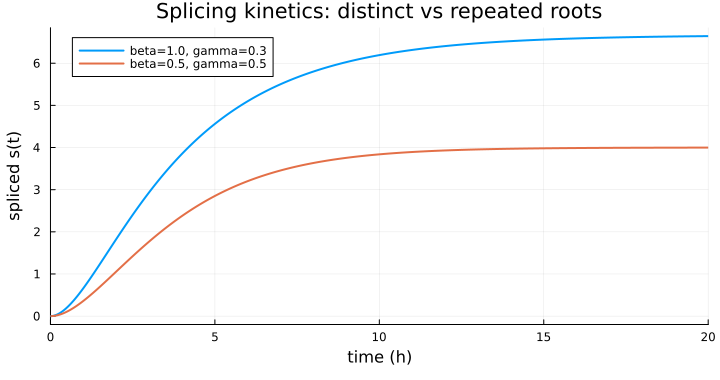

In [10]:
function splicing!(du, x, p, t)
    u, s = x
    du[1] = p.α - p.β * u
    du[2] = p.β * u - p.γ * s
end

s_exact(t, α, β, γ) = β == γ ?
    α/γ * (1 - exp(-γ*t)) - α * t * exp(-γ*t) :
    α/γ * (1 - exp(-γ*t)) + α/(γ - β) * (exp(-γ*t) - exp(-β*t))

plt = plot(xlabel = "time (h)", ylabel = "spliced s(t)", title = "Splicing kinetics: distinct vs repeated roots")
for (β, γ) in ((1.0, 0.3), (0.5, 0.5))
    p = (α = 2.0, β = β, γ = γ)
    sol = solve(ODEProblem(splicing!, [0.0, 0.0], (0.0, 20.0), p), Tsit5(); reltol = 1e-10, abstol = 1e-10)
    err = maximum(abs(sol(t)[2] - s_exact(t, p.α, β, γ)) for t in 0:0.25:20)
    println("β = $β, γ = $γ:  max |Tsit5 - closed form| = ", round(err, sigdigits = 2))
    plot!(plt, sol, idxs = 2, label = "beta=$β, gamma=$γ")
end
plot!(plt, xlabel = "time (h)")   # the solution recipe sets its own "t" label

# Wronskians at t = 1 for the repeated-root case
γ = 0.5
e(t) = exp(-γ*t); de(t) = -γ*exp(-γ*t)
te(t) = t*exp(-γ*t); dte(t) = (1 - γ*t)*exp(-γ*t)
println("W[e^-γt, e^-γt](1)   = ", wronskian2(e, de, e, de, 1.0))
println("W[e^-γt, t e^-γt](1) = ", wronskian2(e, de, te, dte, 1.0), "  (expected e^-2γ = ", exp(-2γ), ")")
plt

## 7. Example 4: Variation of parameters rebuilds the Stein model

> **Primer: the math.**
> * **Homogeneous vs. nonhomogeneous:** $y'' + py' + qy = 0$ is homogeneous. With a nonzero right side $g(t)$ (a **forcing term**, an outside input such as a drug infusion) it is nonhomogeneous.
> * **Structure of every solution:** general solution = (homogeneous part $c_1y_1 + c_2y_2$) + (one **particular** solution $y_p$).
> * **Variation of parameters, the idea:** take the homogeneous solution and let the constants vary, $y_p = u_1(t)\,y_1 + u_2(t)\,y_2$. Requiring this to solve the equation gives two linear equations for $u_1', u_2'$. Their determinant is the Wronskian, so **the method only works when $W \neq 0$**, because the formulas divide by $W$.
> * **Why this example:** the constant forcing below is the mathematical device that produces the "$-1$" in the Stein formula. It is not a claim that tumors receive a constant input. The point is to see the Wronskian do real work inside variation of parameters.

Which ODE does the Stein curve $f(t) = e^{-dt} + e^{gt} - 1$ satisfy? Its homogeneous modes have characteristic roots $-d$ and $g$, so $(r+d)(r-g) = r^2 + (d-g)r - dg$, and the constant $-1$ must come from a forcing term:
$$
y'' + (d - g)\,y' - dg\,y = dg .
$$

**Variation of parameters, by hand.** With $y_1 = e^{-dt}$, $y_2 = e^{gt}$, $W = (g+d)e^{(g-d)t}$ (Example 1), and $g(t) \to G = dg$ (careful: here $g$ is also the growth rate, so the forcing is written $G$):
$$
u_1' = -\frac{y_2 G}{W} = -\frac{dg\, e^{dt}}{g+d} \Rightarrow u_1 = -\frac{g\, e^{dt}}{g+d}, \qquad
u_2' = \frac{y_1 G}{W} = \frac{dg\, e^{-gt}}{g+d} \Rightarrow u_2 = -\frac{d\, e^{-gt}}{g+d},
$$
$$
y_p = u_1 y_1 + u_2 y_2 = -\frac{g}{g+d} - \frac{d}{g+d} = -1. \checkmark
$$
**Abel check:** $p(t) = d - g$, so $W(t) = W(0)\,e^{-(d-g)t} = (g+d)\,e^{(g-d)t}$, matching Example 1.

Matching $f(0) = 1$, $f'(0) = g - d$ gives $c_1 = c_2 = 1$, so the full solution is the Stein model. The cell below verifies this with SciML by rewriting the second-order ODE as a first-order system $(y, y')$, and also evaluates the variation-of-parameters integrals **numerically** to confirm $y_p = -1$.

max |Tsit5 - Stein f(t)| = 8.3e-12


numerical VoP vs closed form at t = 8: 

0.8576700366616193  vs  0.8576700468918459


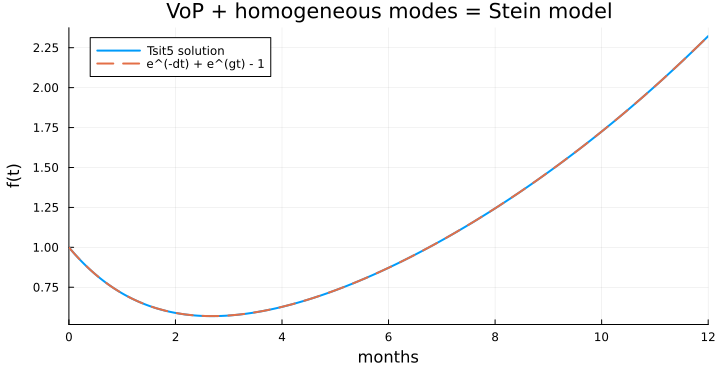

In [11]:
d, g = 0.5, 0.1
G = d * g
stein(t) = exp(-d*t) + exp(g*t) - 1

# 2nd-order ODE as a first-order system: x = (y, y')
second_order(x, p, t) = [x[2], G - (d - g) * x[2] + d * g * x[1]]
solS = solve(ODEProblem(second_order, [1.0, g - d], (0.0, 12.0)), Tsit5(); reltol = 1e-10, abstol = 1e-10)
println("max |Tsit5 - Stein f(t)| = ", round(maximum(abs(solS(t)[1] - stein(t)) for t in 0:0.1:12), sigdigits = 2))

# Numerical variation of parameters (trapezoid rule), integrating from 0
y1(t) = exp(-d*t); y2(t) = exp(g*t); W(t) = (g + d) * exp((g - d) * t)
function trapz(f, a, b; n = 4000)
    h = (b - a) / n
    h * (sum(f(a + i*h) for i in 1:n-1) + (f(a) + f(b)) / 2)
end
yp_num(t) = -y1(t) * trapz(s -> y2(s) * G / W(s), 0, t) + y2(t) * trapz(s -> y1(s) * G / W(s), 0, t)
# Integrating from 0 adds a homogeneous piece: yp_num = -1 + (g e^{-dt} + d e^{gt})/(g+d)
yp_closed(t) = -1 + (g*exp(-d*t) + d*exp(g*t)) / (g + d)
println("numerical VoP vs closed form at t = 8: ", yp_num(8.0), "  vs  ", yp_closed(8.0))   # agree to ~1e-8 (trapezoid-rule error)

plot(solS, idxs = 1, label = "Tsit5 solution", xlabel = "months", ylabel = "f(t)",
     title = "VoP + homogeneous modes = Stein model")
plot!(stein, 0, 12, ls = :dash, label = "e^(-dt) + e^(gt) - 1")

**Note.** Variation of parameters with definite integrals from $t_0 = 0$ returns $y_p$ **plus** a homogeneous combination; any two particular solutions differ by $c_1y_1 + c_2y_2$. That is exactly why the Wronskian (independence of $y_1, y_2$) guarantees that the initial conditions can always absorb the difference.

## 8. Example 5: Spatial transcriptomics: a signal gradient from the tumor edge

> **Primer: the biology.** **Next-generation sequencing (NGS)** reads millions of DNA/RNA fragments in parallel. **Spatial transcriptomics** (Ståhl et al. 2016; review: Moses & Pachter 2022) adds *location*: a tissue section is placed on a slide covered with barcoded capture **spots**, so every sequenced RNA molecule is tagged with the spot it came from. (On the widely used 10x Visium slides, spots are 55 µm across, about 100 µm apart center to center.) The result is a gene-expression map of the tissue, recorded as **UMI counts**: the number of distinct RNA molecules of each gene captured at each spot. (A UMI, or unique molecular identifier, is a random barcode that lets duplicate reads of the same molecule be counted once.)
>
> A common question in tumor sections is **how expression changes with distance from the tumor edge**. Suppose tumor cells secrete a signaling molecule (a cytokine or growth factor) at the boundary. It **diffuses** into the surrounding tissue and is **degraded** or taken up as it goes, so neighboring cells see a concentration that falls with distance. A responder gene in those cells then shows a matching **expression gradient** across the spots.
>
> **Primer: the math.**
> * **Diffusion + degradation at steady state:** with concentration $c(x)$ at distance $x$, diffusion coefficient $D$ and degradation rate $k$, the balance $D\,c'' = k\,c$ gives
> $$c'' = \frac{1}{\ell^2}\,c, \qquad \ell = \sqrt{D/k}\ \ \text{(the decay length)}.$$
> This is a **second-order linear ODE in space** instead of time. The Wronskian works exactly the same with $x$ as the variable.
> * **Characteristic roots** $\pm 1/\ell$ give the modes $e^{-x/\ell}$ and $e^{x/\ell}$, equivalently $\cosh(x/\ell)$ and $\sinh(x/\ell)$.
> * **Boundary-value problem (BVP):** instead of a value and slope at one point (an initial-value problem), there is one condition at each end: $c(0) = 1$ (concentration fixed at the tumor edge) and $c'(L) = 0$ (no flux out of the far edge of the tissue at $x = L$).
> * **Shooting with a fundamental set:** solve two initial-value problems, $Y_1$ with $(Y_1, Y_1')(0) = (1, 0)$ and $Y_2$ with $(Y_2, Y_2')(0) = (0, 1)$. Every solution is $c = Y_1 + sY_2$ (the value $c(0) = 1$ is already built in), and the unknown starting slope $s$ is chosen to satisfy $c'(L) = 0$. Because $W[Y_1, Y_2] \neq 0$, this works and $s$ is unique.

**Wronskian facts for this equation:**
* $W[e^{-x/\ell}, e^{x/\ell}] = 2/\ell \neq 0$ and $W[\cosh(x/\ell), \sinh(x/\ell)] = 1/\ell \neq 0$.
* For the shooting pair, Abel's identity gives $W[Y_1, Y_2](x) = W(0) = 1$ for all $x$, because the equation has no $c'$ term.
* The exact BVP solution is $c(x) = \dfrac{\cosh\big((L - x)/\ell\big)}{\cosh(L/\ell)}$.

**Contrast, worth knowing for the BVP unit:** if the equation were oscillatory, $c'' = -\omega^2 c$, the shooting solution $Y_2 = \sin(\omega x)/\omega$ can vanish at the far end. Then some BVPs have **no** solution or **infinitely many**. Diffusion with degradation never has this problem.

**Plan:** (1) solve the BVP with SciML by shooting and check the Wronskian is constant; (2) simulate a spot-level spatial dataset (counts at 300 spots); (3) estimate the decay length $\ell$ from the counts.

In [12]:
L  = 500.0          # tissue depth from the tumor edge (micrometers)
ℓ  = 100.0          # true decay length sqrt(D/k) (micrometers)

gradient_ode(c, ℓ, x) = [c[2], c[1] / ℓ^2]      # state (c, c'), independent variable is x
Y1 = solve(ODEProblem(gradient_ode, [1.0, 0.0], (0.0, L), ℓ), Tsit5(); reltol = 1e-10, abstol = 1e-12)
Y2 = solve(ODEProblem(gradient_ode, [0.0, 1.0], (0.0, L), ℓ), Tsit5(); reltol = 1e-10, abstol = 1e-12)

Wsp(x) = Y1(x)[1] * Y2(x)[2] - Y1(x)[2] * Y2(x)[1]
println("Wronskian of the shooting pair at x = 0, 250, 500: ", round.([Wsp(0.0), Wsp(250.0), Wsp(L)], digits = 8))

s_slope = -Y1(L)[2] / Y2(L)[2]                  # choose the slope so that c'(L) = 0
c_shoot(x) = Y1(x)[1] + s_slope * Y2(x)[1]
c_exact(x) = cosh((L - x) / ℓ) / cosh(L / ℓ)
println("max |shooting - exact| = ", round(maximum(abs(c_shoot(x) - c_exact(x)) for x in 0:5:L), sigdigits = 2))

Wronskian of the shooting pair at x = 0, 250, 500: 

[1.0, 1.0, 1.0]
max |shooting - exact| = 3.4e-10

estimated decay length = 113.0 um (truth 100.0);  baseline, amplitude = 

[1.26, 29.29]
design-matrix cond at l = 100: 4.09   at l = 20000: 21200.0


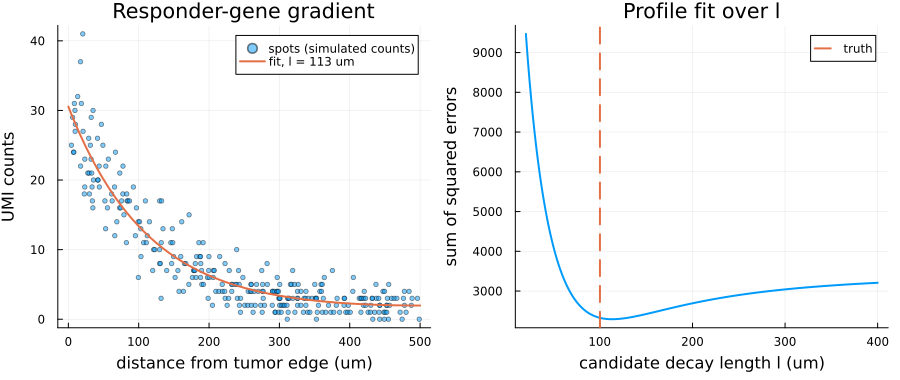

In [13]:
# Simulated spot data: 300 spots at random distances from the tumor edge.
# Expected counts of a responder gene = baseline + amplitude * concentration.
import Random; Random.seed!(2)
function poisson_draw(μ)                       # simple Poisson sampler (Knuth), fine for small means
    k, p, u = 0, exp(-μ), rand()
    cum = p
    while u > cum
        k += 1; p *= μ / k; cum += p
    end
    k
end
xs     = sort(rand(300) .* L)
counts = poisson_draw.(2.0 .+ 30.0 .* c_exact.(xs))     # true baseline 2, amplitude 30

# Fit: for each candidate decay length, the model is LINEAR in (baseline, amplitude) -> least squares.
profile_shape(x, l) = cosh((L - x) / l) / cosh(L / l)
function fit_at(l)
    A = hcat(ones(length(xs)), profile_shape.(xs, l))
    coef = A \ counts
    (rss = sum(abs2, counts .- A * coef), coef = coef, cond = cond(A))
end
lgrid = 20.0:1.0:400.0
rss   = [fit_at(l).rss for l in lgrid]
lhat  = lgrid[argmin(rss)]
best  = fit_at(lhat)
println("estimated decay length = $lhat um (truth $ℓ);  baseline, amplitude = ", round.(best.coef, digits = 2))
println("design-matrix cond at l = 100: ", round(fit_at(100.0).cond, sigdigits = 3),
        "   at l = 20000: ", round(fit_at(20000.0).cond, sigdigits = 3))

p1 = scatter(xs, counts, ms = 2.5, alpha = 0.5, label = "spots (simulated counts)",
             xlabel = "distance from tumor edge (um)", ylabel = "UMI counts", title = "Responder-gene gradient")
plot!(p1, x -> best.coef[1] + best.coef[2] * profile_shape(x, lhat), 0, L, label = "fit, l = $(Int(lhat)) um")
p2 = plot(lgrid, rss, xlabel = "candidate decay length l (um)", ylabel = "sum of squared errors",
          label = "", title = "Profile fit over l")
vline!(p2, [ℓ], ls = :dash, label = "truth")
plot(p1, p2, layout = (1, 2), size = (900, 380))

**Reading it.**
* The Wronskian of the shooting pair stays exactly 1 across the tissue, as Abel's identity predicts, so the BVP has exactly one solution and shooting finds it.
* From 300 noisy spots, the estimated decay length lands near the true 100 µm (about 113 µm with this random seed). The profile curve on the right has a clear minimum, but it is shallow on the right side, so longer decay lengths are only mildly penalized. That is a hint of the identifiability issue below.
* The last printout repeats the lesson of Example 1. When the candidate decay length is huge, the gradient shape becomes almost flat, nearly parallel to the baseline column of 1s. The design matrix becomes badly conditioned, and baseline and amplitude can no longer be told apart. **Independent building blocks are what make parameters recoverable from sequencing data.**

**Where this goes in real work:** fitting gradients like this per gene across many spots (with count models such as the negative binomial instead of plain least squares), adding a second spatial dimension (a PDE, the heat-equation unit of the course), and coupling several secreted signals into reaction–diffusion systems solved with SciML.

## 9. Plain-language glossary + roadmap

### 9.1 Glossary for the roadmap
* **Linearization / Jacobian:** most real biological models are *nonlinear*. Near a steady state (an equilibrium), they behave approximately like a linear system $\mathbf{x}' = J\mathbf{x}$, where $J$ (the **Jacobian**) is the matrix of partial derivatives. All the linear tools in this notebook then apply. The eigenvalues of $J$ say whether the steady state is stable.
* **Sensitivity analysis:** asks "if this rate constant changes a little, how much does the model output change?" The sensitivities themselves obey a *linear* ODE, so fundamental matrices appear again.
* **Structural identifiability:** with perfect, noise-free data, *could* the parameters be determined uniquely? If two parameters only ever appear as a product, for example, no experiment can separate them.
* **Practical identifiability:** with *real*, noisy, limited data, *are* the parameters pinned down? This is what Examples 1 and 5 showed with the condition number.
* **Parameter inference:** fitting a model to data, either by optimization (best fit) or with Bayesian methods (a full distribution of plausible values).
* **Neural ODE / universal differential equation (UDE):** an ODE in which some or all of the right-hand side is a **neural network** trained on data. In a UDE, known biology (for example growth terms) is written by hand and only the unknown part (for example how a drug kills cells) is learned.
* **Omics snapshots:** sequencing destroys the sample, so each cell or spot is measured once. Dynamics must be *inferred*, for example from spliced/unspliced ratios (Example 3) or spatial position (Example 5).

### 9.2 Roadmap: from the Wronskian to AI/ML in cancer genomics

The Wronskian answers one question: **are these components independent?** Each rung below asks the same question about a bigger object.

| Step | Concept | Cancer comp-bio use | Julia/SciML tools |
|---|---|---|---|
| 1 | **Wronskian / fundamental set** (this notebook) | Two-mode tumor response; repeated-root traps in kinetic models | `OrdinaryDiffEqTsit5` |
| 2 | **Fundamental matrix, $e^{At}$, eigenvalues** | Linear compartment / clone models; RNA velocity kinetics | `LinearAlgebra` |
| 3 | **Linearization (Jacobian) & stability** of nonlinear models | Tumor–immune, logistic/Gompertz growth, signaling (MAPK, p53–Mdm2 oscillations) equilibria | `ModelingToolkit.jl` |
| 4 | **Sensitivity analysis.** Forward sensitivities solve a *linear* ODE driven by the Jacobian, so fundamental-matrix theory applies | Which rate constants move the tumor-burden or drug-response curve? | `SciMLSensitivity.jl` |
| 5 | **Structural identifiability.** Can parameters be recovered from ideal data? Wronskians of monomials in input–output equations test linear independence (Ovchinnikov, Pogudin & Thompson) | Is $g$ recoverable separately from $d$? Can $\beta$ and $\gamma$ be separated in RNA velocity? | `StructuralIdentifiability.jl` |
| 6 | **Practical identifiability / parameter inference** (Fisher information rank, profile likelihood, Bayesian posteriors) | Fitting longitudinal tumor sizes, PSA, ctDNA; Example 1's conditioning is the toy version | `Optimization.jl`, `Turing.jl` |
| 7 | **Hybrid mechanistic + ML: universal differential equations (UDEs) / neural ODEs.** Known biology is written as ODE terms and the unknown terms are learned by a neural network (Rackauckas et al. 2020; Chen et al. 2018) | Learn an unknown drug-effect or immune-kill term from patient time series while keeping interpretable growth terms | `DiffEqFlux.jl`, `Lux.jl` |
| 8 | **Dynamics from omics snapshots** | RNA velocity / latent time in tumor single-cell data (Example 3); clonal dynamics from multi-region or longitudinal sequencing | scVelo (Python) + SciML for custom kinetics |
| 9 | **Space: BVPs → reaction–diffusion PDEs** | Signal and hypoxia gradients across spatial-transcriptomics spots; tumor–stroma boundaries (Example 5) | `OrdinaryDiffEqTsit5` (shooting), `BoundaryValueDiffEq.jl`, `MethodOfLines.jl` |

**A suggested project path for a student:**
1. Re-derive Examples 1–4 with paper and pencil (course mastery).
2. Fit the Stein model to a public longitudinal tumor-size dataset, and report confidence intervals for $g$ and $d$ (steps 1, 6).
3. Run `StructuralIdentifiability.jl` on the clone model when only **total** burden $S+R$ is observed: which parameters are identifiable? (step 5)
4. Replace the constant kill rate $k$ with a neural network $k_\theta(t)$ and train it as a UDE on simulated data (step 7).
5. Read the scVelo dynamical model and connect its per-gene $(\alpha, \beta, \gamma)$ fits to Example 3 (step 8).
6. Take a public tumor spatial-transcriptomics dataset, compute each spot's distance to the annotated tumor boundary, and fit Example 5's gradient model to a few genes (step 9).

**Where the Wronskian is *not* the right tool:** cancer genomics workhorses such as PCA, regression, likelihood models, hidden Markov models and mutational-signature factorization use other linear-algebra notions of independence (rank, singular values, conditioning). Example 1's condition number is the bridge between the two worlds.

## 10. Exercises

1. Compute $W[e^{-dt}, e^{gt}, 1]$ (3×3). Is the Stein model's constant term an independent third mode of some third-order homogeneous ODE?
2. In Example 2, change $r$ so that $\operatorname{tr}A = 0$. What happens to $\det X(t)$, and what does it mean geometrically (volume in the $(S, R)$ plane)?
3. In Example 3, set $\beta = \gamma + 10^{-8}$ and evaluate the $\beta \neq \gamma$ closed form at $t = 5$. Compare with `Tsit5`. Why is the closed form numerically dangerous near the repeated root?
4. Use variation of parameters for $y'' + (d-g)y' - dg\,y = e^{-t}$ (a decaying drug infusion). Check the answer with `Tsit5`.
5. Show that for $\mathbf{x}' = A\mathbf{x}$ with constant $A$, $\det e^{At} = e^{t\,\operatorname{tr}A}$ using eigenvalues (assume $A$ is diagonalizable).
6. In Example 5, change the far-edge condition to $c(L) = 0$ (the signal is fully absorbed at $x = L$). Redo the shooting step. Which entry of $Y_1, Y_2$ now appears in the denominator, and why is it never zero?
7. Compute $W[e^{t}, e^{-t}]$ and $W[\cosh t, \sinh t]$ by hand. Both pairs solve $y'' = y$; why do the two Wronskians differ by a constant factor?

## 11. References

**ODE theory (Wronskian, Abel's identity, variation of parameters, fundamental matrices)**
1. Nagle, R. K., Saff, E. B., & Snider, A. D. *Fundamentals of Differential Equations*, 9th ed. Pearson (2018). Chapters on linear second-order equations, the theory of higher-order linear equations, and linear systems in normal form.
2. Boyce, W. E., DiPrima, R. C., & Meade, D. B. *Elementary Differential Equations and Boundary Value Problems*, 11th ed. Wiley (2017). Sections on fundamental solutions, Abel's theorem and the Wronskian of systems.
3. Peano, G. (1889). "Sur le déterminant wronskien." *Mathesis* 9, 75–76. The original $W \equiv 0$ but independent counterexample. See also Bostan, A. & Dumas, P. (2010). "Wronskians and linear independence." *American Mathematical Monthly* 117(8), 722–727. https://doi.org/10.4169/000298910X515785

**SciML / Julia**

4. Rackauckas, C. & Nie, Q. (2017). "DifferentialEquations.jl: A performant and feature-rich ecosystem for solving differential equations in Julia." *Journal of Open Research Software* 5(1):15. https://doi.org/10.5334/jors.151
5. DifferentialEquations.jl documentation, *Getting Started with Differential Equations in Julia*. https://docs.sciml.ai/DiffEqDocs/stable/getting_started/
6. Rackauckas, C. et al. (2020). "Universal Differential Equations for Scientific Machine Learning." arXiv:2001.04385. https://arxiv.org/abs/2001.04385
7. Chen, R. T. Q., Rubanova, Y., Bettencourt, J. & Duvenaud, D. (2018). "Neural Ordinary Differential Equations." *NeurIPS 2018*. arXiv:1806.07366. https://arxiv.org/abs/1806.07366

**Identifiability**

8. Ovchinnikov, A., Pogudin, G. & Thompson, P. (2023). "Input-output equations and identifiability of linear ODE models." *IEEE Transactions on Automatic Control* 68(2), 812–824. https://doi.org/10.1109/TAC.2022.3145571 (preprint: arXiv:1910.03960)
9. Dong, R., Goodbrake, C., Harrington, H. A. & Pogudin, G. (2023). "Differential elimination for dynamical models via projections with applications to structural identifiability." *SIAM Journal on Applied Algebra and Geometry* 7(1), 194–235. (Algorithm behind `StructuralIdentifiability.jl`.)

**Cancer and genomics applications**

10. Stein, W. D., Gulley, J. L., Schlom, J., Madan, R. A., Dahut, W., Figg, W. D. et al. (2011). "Tumor regression and growth rates determined in five intramural NCI prostate cancer trials: the growth rate constant as an indicator of therapeutic efficacy." *Clinical Cancer Research* 17(4), 907–917. https://doi.org/10.1158/1078-0432.CCR-10-1762
11. Foo, J. & Michor, F. (2009). "Evolution of resistance to targeted anti-cancer therapies during continuous and pulsed administration strategies." *PLoS Computational Biology* 5(11), e1000557. https://doi.org/10.1371/journal.pcbi.1000557
12. La Manno, G. et al. (2018). "RNA velocity of single cells." *Nature* 560, 494–498. https://doi.org/10.1038/s41586-018-0414-6
13. Bergen, V., Lange, M., Peidli, S., Wolf, F. A. & Theis, F. J. (2020). "Generalizing RNA velocity to transient cell states through dynamical modeling." *Nature Biotechnology* 38, 1408–1414. https://doi.org/10.1038/s41587-020-0591-3
14. Ståhl, P. L. et al. (2016). "Visualization and analysis of gene expression in tissue sections by spatial transcriptomics." *Science* 353(6294), 78–82. https://doi.org/10.1126/science.aaf2403
15. Moses, L. & Pachter, L. (2022). "Museum of spatial transcriptomics." *Nature Methods* 19, 534–546. https://doi.org/10.1038/s41592-022-01409-2
16. Gerlee, P. (2013). "The model muddle: in search of tumor growth laws." *Cancer Research* 73(8), 2407–2411. https://doi.org/10.1158/0008-5472.CAN-12-4355